In [1]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset
import scipy as sp

import datetime
import cftime
import time

import gsw

In [2]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridT.nc")
ds_t12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridT.nc")

In [3]:
ds_t4

<xarray.Dataset> Size: 2GB
Dimensions:               (deptht: 50, axis_nbounds: 2, depthw: 50,
                           time_counter: 1, y_grid_T: 800, x_grid_T: 544,
                           y_grid_W: 800, x_grid_W: 544)
Coordinates:
  * deptht                (deptht) float32 200B 0.494 1.541 ... 5.728e+03
  * depthw                (depthw) float32 200B 0.0 1.011 ... 5.052e+03 5.5e+03
  * time_counter          (time_counter) object 8B 2018-05-23 12:00:00
    time_centered         (time_counter) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    nav_lat_grid_T        (y_grid_T, x_grid_T) float32 2MB dask.array<chunksize=(800, 544), meta=np.ndarray>
    nav_lon_grid_T        (y_grid_T, x_grid_T) float32 2MB dask.array<chunksize=(800, 544), meta=np.ndarray>
    nav_lat_grid_W        (y_grid_W, x_grid_W) float32 2MB dask.array<chunksize=(800, 544), meta=np.ndarray>
    nav_lon_grid_W        (y_grid_W, x_grid_W) float32 2MB dask.array<chunksize=(800, 544), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y_grid_T, x_grid_T, y_grid_W,
                                x_grid_W
Data variables: (12/26)
    deptht_bounds         (deptht, axis_nbounds) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
    depthw_bounds         (depthw, axis_nbounds) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
    votemper              (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) object 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) object 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    vosaline              (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    ...                    ...
    TRC09                 (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    TRC10                 (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    TRC11                 (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    TRC12                 (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    TRC13                 (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    e3t                   (time_counter, deptht, y_grid_T, x_grid_T) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
Attributes:
    name:         ANHA4-EPM151
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2022-Dec-04 10:33:38 EST

In [99]:
def make_land_mask(ds, inds):
    return np.ma.make_mask(ds['vosaline'][0,0,inds[0]:inds[1], inds[2]:inds[3]] != 0)

def isopycnal_interp(ds, inds, isopycnal):
    try:
        s = gsw.SA_from_Sstar(ds['vosaline'] * (35.16504/35), 10.1325, ds.nav_lon_grid_T, ds.nav_lat_grid_T)
    except: 
        s = gsw.SA_from_Sstar(ds['vosaline'] * (35.16504/35), 10.1325, ds.nav_lon, ds.nav_lat)
        
    rho = gsw.sigma0(s, ds['votemper'])[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    rho = np.where(rho > 0, rho, np.nan)

    iso = isopycnal
    residuals = rho - iso

    stacked_ones = np.vstack([residuals, np.ones((1, rho[0,:,:].shape[0], rho[0,:,:].shape[1]))])
    #print(stacked_ones.shape)
    depths = np.stack([np.stack([ds.deptht] * rho[0,:,:].shape[0], axis=1)]*rho[0,:,:].shape[1], axis=2)
    #print(depths.shape)
        
    schange = stacked_ones[:-1,:,:] * stacked_ones[1:,:,:]
    #print(schange.shape)

    m_rho = np.ma.make_mask(schange < 0)
    m_rho1 = np.insert(m_rho, 0, np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1])).astype(bool), axis=0)[:-1,:,:]

    rho1 = np.nansum(np.where(m_rho, rho, np.nan), axis=0)
    rho2 = np.nansum(np.where(m_rho1, rho, np.nan), axis=0)
    #print(rho2.shape)

    z1 = np.nansum(np.where(m_rho, depths, np.nan), axis=0)
    z2 = np.nansum(np.where(m_rho1, depths, np.nan), axis=0)
    #print(z2.shape)

    zs2interp = np.stack([z1,z2], axis=0) #monotonically increasing down
    rhos2interp = np.stack([rho1,rho2], axis=0) #monotonically increasing down

    interp_outz = np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1]))
    #print(interp_outz.shape)

    for x in range(rho[0,:,:].shape[0]):
        for y in range(rho[0,:,:].shape[1]):
            interp_outz[x,y] = np.interp(iso, rhos2interp[:,x,y], zs2interp[:,x,y])
            
    land_mask = make_land_mask(ds_t4, inds)
    #print(land_mask.shape)

    return [m_rho, m_rho1, interp_outz, zs2interp, land_mask]


def isopycnal_proj(var_proj, inds, interprod):
    var = var_proj[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    var1 = np.nansum(np.where(interprod[0], var, np.nan), axis=0)
    #print(var1.shape)
    var2 = np.nansum(np.where(interprod[1], var, np.nan), axis=0)
    #print(var2.shape)

    interp_vars = np.stack([var1,var2], axis=0)

    var_out = np.zeros((interprod[4].shape[0], interprod[4].shape[1]))
    #print(var_out.shape)

    for x in range(interprod[4].shape[0]):
        for y in range(interprod[4].shape[1]):
            var_out[x,y] = np.interp(interprod[2][x,y], interprod[3][:,x,y], interp_vars[:,x,y])
        
    var_out = np.where(interprod[4], var_out, np.nan)

    return var_out
    

In [100]:
rho_goal = 27.8
interprods = isopycnal_interp(ds_t4, [250,450,150,375], rho_goal)

In [101]:
projection = isopycnal_proj(ds_t4['vosaline'], [250,450,150,375], interprods)

In [82]:
"""
class nlcmap():
    "A nonlinear colormap"
    
    name = 'nlcmap'
    
    def __init__(self, cmap, levels):
        self.cmap = cmap
        # @MRR: Need to add N for backend
        self.N = cmap.N
        self.monochrome = self.cmap.monochrome
        self.levels = asarray(levels, dtype='float64')
        self._x = self.levels / self.levels.max()
        self._y = linspace(0.0, 1.0, len(self.levels))
    
    #@MRR Need to add **kw for 'bytes'
    def __call__(self, xi, alpha=1.0, **kw):
        "docstring for fname
        # @MRR: Appears broken? 
        # It appears something's wrong with the
        # dimensionality of a calculation intermediate
        #yi = stineman_interp(xi, self._x, self._y)
        yi = interp(xi, self._x, self._y)
        return self.cmap(yi, alpha)


if __name__ == '__main__':
    
    y, x = mgrid[0.0:3.0:100j, 0.0:5.0:100j]
    H = 50.0 * exp( -(x**2 + y**2) / 4.0 )
    levels = [0, 1, 2, 3, 6, 9, 20, 50]
    
    cmap_lin = cm.jet
    cmap_nonlin = nlcmap(cmap_lin, levels)
    
    subplot(2,1,1)
    contourf(x, y, H, levels, cmap=cmap_nonlin)
    colorbar()
    subplot(2,1,2)
    contourf(x, y, H, levels, cmap=cmap_lin)
    colorbar()
    
    savefig('nlcmap_example.png')
"""

'\nclass nlcmap():\n    "A nonlinear colormap"\n\n    name = \'nlcmap\'\n\n    def __init__(self, cmap, levels):\n        self.cmap = cmap\n        # @MRR: Need to add N for backend\n        self.N = cmap.N\n        self.monochrome = self.cmap.monochrome\n        self.levels = asarray(levels, dtype=\'float64\')\n        self._x = self.levels / self.levels.max()\n        self._y = linspace(0.0, 1.0, len(self.levels))\n\n    #@MRR Need to add **kw for \'bytes\'\n    def __call__(self, xi, alpha=1.0, **kw):\n        "docstring for fname\n        # @MRR: Appears broken? \n        # It appears something\'s wrong with the\n        # dimensionality of a calculation intermediate\n        #yi = stineman_interp(xi, self._x, self._y)\n        yi = interp(xi, self._x, self._y)\n        return self.cmap(yi, alpha)\n\n\nif __name__ == \'__main__\':\n\n    y, x = mgrid[0.0:3.0:100j, 0.0:5.0:100j]\n    H = 50.0 * exp( -(x**2 + y**2) / 4.0 )\n    levels = [0, 1, 2, 3, 6, 9, 20, 50]\n\n    cmap_lin = cm

In [102]:
kmap = mpl.cm.viridis.copy()

In [103]:
kmap.N

256

In [115]:
n = 20

In [107]:
a=np.nanmax(projection)

In [108]:
b=np.nanmin(projection[projection !=0])

In [117]:
level = np.linspace(b, b + (a-b)/2, int(n/4))

In [118]:
level2 = np.linspace(b + (a-b)/2, a, 3*int(n/4)) 

In [120]:
levels = np.append(level, [level2])

In [121]:
levels

array([34.73227907, 34.77301281, 34.81374656, 34.8544803 , 34.89521404,
       34.89521404, 34.90685225, 34.91849046, 34.93012867, 34.94176689,
       34.9534051 , 34.96504331, 34.97668152, 34.98831973, 34.99995794,
       35.01159616, 35.02323437, 35.03487258, 35.04651079, 35.058149  ])

In [ ]:
def make_nonlinear_cb(cb, levels):
    cmap = mpl.cm.cb.copy()
    
    

Text(0.5, 0, 'Longitude')

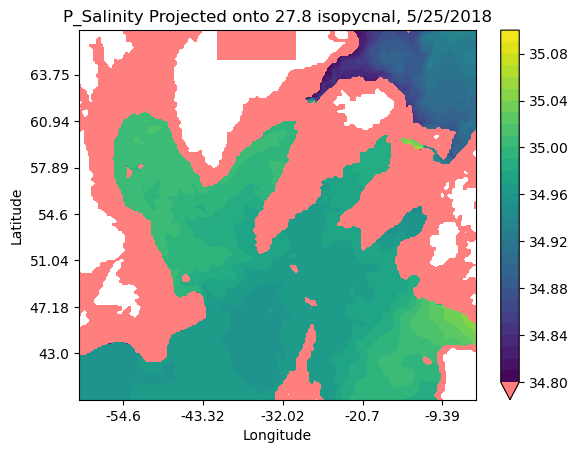

In [76]:
cmap = mpl.cm.viridis.copy() # Make a copy to avoid changing the original
cmap.set_under('red', alpha=.5)
cmap.set_over('yellow', alpha=.5)
plt.contourf(projection, np.arange(34.8, 35.1, .01),cmap=cmap, extend='min')
plt.colorbar()
plt.title("P_Salinity Projected onto " + str(rho_goal) + " isopycnal, 5/25/2018")
plt.yticks(np.arange(25,200, 25), np.trunc(ds_t4.nav_lat_grid_T.values[275:450, 150][::25] * 100) / 100)
plt.xticks(np.arange(25,225, 45), np.trunc(ds_t4.nav_lon_grid_T.values[250, 175:375][::45] * 100) / 100)
plt.ylabel('Latitude')
plt.xlabel('Longitude')

Text(0.5, 0, 'Longitude')

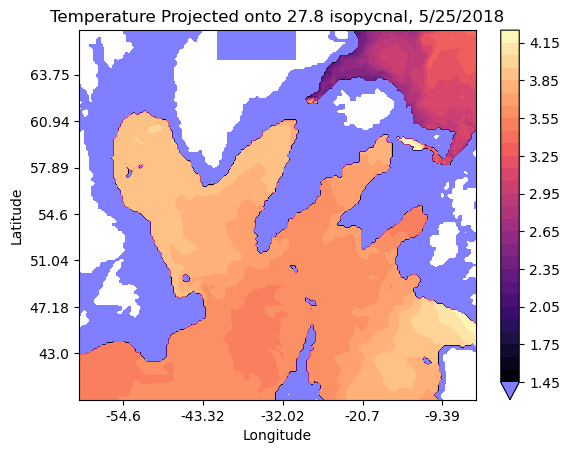

In [94]:
cmap = mpl.cm.magma.copy() # Make a copy to avoid changing the original
cmap.set_under('blue', alpha=.5)
cmap.set_over('yellow', alpha=.5)
plt.contourf(projection, np.arange(1.45,4.35, .1), cmap=cmap, extend='min')
plt.colorbar()
plt.title("Temperature Projected onto " + str(rho_goal) + " isopycnal, 5/25/2018")
plt.yticks(np.arange(25,200, 25), np.trunc(ds_t4.nav_lat_grid_T.values[275:450, 150][::25] * 100) / 100)
plt.xticks(np.arange(25,225, 45), np.trunc(ds_t4.nav_lon_grid_T.values[250, 175:375][::45] * 100) / 100)
plt.ylabel('Latitude')
plt.xlabel('Longitude')

In [ ]:
cmap = mpl.cm.magma.copy() # Make a copy to avoid changing the original
cmap.set_under('blue', alpha=.5)
cmap.set_over('yellow', alpha=.5)
plt.contourf(projection, np.arange(1.45,4.35, .1), cmap=cmap, extend='min')
plt.colorbar()
plt.title("Temperature Projected onto " + str(rho_goal) + " isopycnal, 5/25/2018")
plt.yticks(np.arange(25,200, 25), np.trunc(ds_t4.nav_lat_grid_T.values[275:450, 150][::25] * 100) / 100)
plt.xticks(np.arange(25,225, 45), np.trunc(ds_t4.nav_lon_grid_T.values[250, 175:375][::45] * 100) / 100)
plt.ylabel('Latitude')
plt.xlabel('Longitude')

In [91]:
np.nanmin(projection[projection !=0])

np.float64(1.4561838782140364)